# **Подготовка окружения и загрузка данных**

In [ ]:
# Импорт базовых библиотек для работы с массивами, файлами и графиками
import os
import time
import math
import random
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt
import gdown

# Импорт инструментов для извлечения признаков из аудио
import librosa
import librosa.display

# Импорт компонентов глубокого обучения (Keras / TensorFlow)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM, concatenate
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical

# Импорт утилит для предобработки данных и оценки моделей из sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Настройки среды
warnings.filterwarnings('ignore')
%matplotlib inline

print("Библиотеки успешно импортированы!")

# --- Загрузка и распаковка датасета ---
DATASET_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip'
gdown.download(DATASET_URL, None, quiet=False)

# Распаковка архива во временное хранилище Colab
!unzip -qo genres.zip
print("Архив успешно распакован. Содержимое директории 'genres':")
!ls genres

# --- Конфигурация констант ---
FILE_DIR = './genres'                     # Корневая папка датасета
CLASS_LIST = os.listdir(FILE_DIR)         # Извлечение списка жанров
CLASS_LIST.sort()                         # Сортировка для жесткой фиксации порядка меток
CLASS_COUNT = len(CLASS_LIST)             # Количество классов (10)
CLASS_FILES = 100                         # Файлов в каждом жанре

DURATION_SEC = 30                         # Длительность трека для анализа (сек)
N_FFT = 8192                              # Размер окна преобразования Фурье
HOP_LENGTH = 512                          # Шаг скользящего окна

print(f"\nКонстанты инициализированы. Обнаружено классов: {CLASS_COUNT}")
print(f"Список жанров: {CLASS_LIST}")

Библиотеки успешно импортированы!


Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip
To: /content/genres.zip
100%|██████████| 1.23G/1.23G [01:21<00:00, 15.1MB/s]


Архив успешно распакован. Содержимое директории 'genres':
blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock

Константы инициализированы. Обнаружено классов: 10
Список жанров: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


# **Разведочный анализ и параметризация аудиосигналов**

Тестовый файл загружен. Длина сигнала: 661500 отсчетов, Частота дискретизации: 22050 Гц


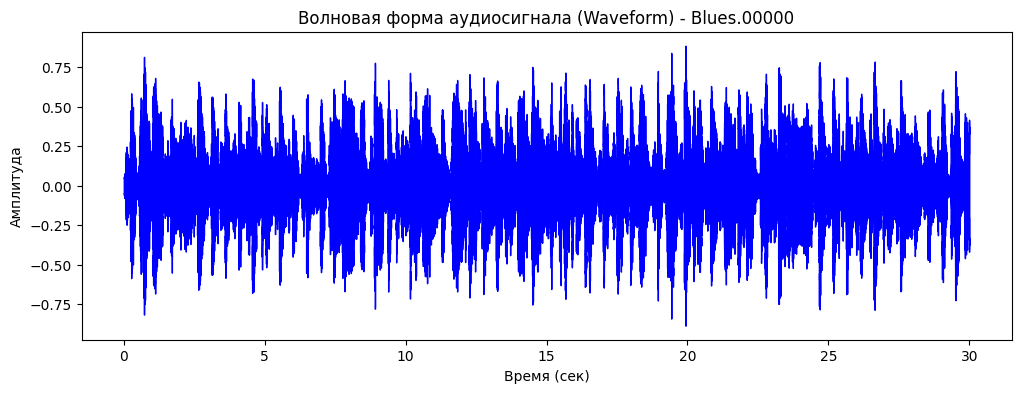

Размерность усредненного вектора признаков для одного файла: (37,)


In [ ]:
def get_features(y, sr, n_fft=N_FFT, hop_length=HOP_LENGTH, aggregate=True):
    """
    Экстракция спектральных и временных признаков аудиосигнала.
    Если aggregate=True, возвращает усредненный вектор признаков (размерность ~37).
    Если aggregate=False, возвращает полный временной трек признаков (матрица).
    """
    # 1. Извлечение параметров с помощью librosa
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    rmse = librosa.feature.rms(y=y, hop_length=hop_length)
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    zcr = librosa.feature.zero_crossing_rate(y=y, hop_length=hop_length)

    if aggregate:
        # Усреднение по оси времени (ось 1)
        features = np.hstack([
            np.mean(chroma_stft, axis=1),
            np.mean(mfcc, axis=1),
            np.mean(rmse, axis=1),
            np.mean(spec_cent, axis=1),
            np.mean(spec_bw, axis=1),
            np.mean(rolloff, axis=1),
            np.mean(zcr, axis=1)
        ])
    else:
        # Слияние матриц признаков по вертикали
        features = np.vstack([chroma_stft, mfcc, rmse, spec_cent, spec_bw, rolloff, zcr]).T

    return features

# Визуализационный тест (EDA)
# Загрузим один случайный файл из жанра 'blues' для проверки
test_file_path = os.path.join(FILE_DIR, 'blues/blues.00000.au')
y, sr = librosa.load(test_file_path, duration=DURATION_SEC)

print(f"Тестовый файл загружен. Длина сигнала: {len(y)} отсчетов, Частота дискретизации: {sr} Гц")

# Построение графика волновой формы
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title("Волновая форма аудиосигнала (Waveform) - Blues.00000")
plt.xlabel("Время (сек)")
plt.ylabel("Амплитуда")
plt.show()

# Проверка размерности признаков
feat_vector = get_features(y, sr, aggregate=True)
print(f"Размерность усредненного вектора признаков для одного файла: {feat_vector.shape}")

# **Предобработка данных и формирование датасета**

In [ ]:
x_data = []
y_data = []

start_time = time.time()
print("Начало извлечения признаков из базы данных аудио...")

# Проходим циклом по всем папкам жанров
for class_idx, class_name in enumerate(CLASS_LIST):
    class_path = os.path.join(FILE_DIR, class_name)
    file_list = os.listdir(class_path)

    print(f"Обработка жанра: {class_name}...")

    for file_name in file_list:
        file_path = os.path.join(class_path, file_name)
        try:
            # Загрузка аудиосигнала
            y, sr = librosa.load(file_path, duration=DURATION_SEC)
            # Извлечение признаков (используем усреднение для классической полносвязной сети)
            features = get_features(y, sr, aggregate=True)

            x_data.append(features)
            y_data.append(class_idx)
        except Exception as e:
            print(f"Ошибка при обработке файла {file_name}: {e}")

x_data = np.array(x_data)
y_data = np.array(y_data)

print(f"\nИзвлечение завершено за {round(time.time() - start_time, 2)} сек.")
print(f"Форма x_data: {x_data.shape}, Форма y_data: {y_data.shape}")

# --- Разделение на обучающую и проверочную выборки ---
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.1, stratify=y_data, random_state=42
)

# --- Масштабирование/Нормализация данных ---
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# --- One-Hot Encoding меток ---
y_train_cat = to_categorical(y_train, num_classes=CLASS_COUNT)
y_test_cat = to_categorical(y_test, num_classes=CLASS_COUNT)

print("\nДанные подготовлены к подаче в нейросеть:")
print(f"Обучающая выборка: x = {x_train_scaled.shape}, y = {y_train_cat.shape}")
print(f"Тестовая выборка: x = {x_test_scaled.shape}, y = {y_test_cat.shape}")

Начало извлечения признаков из базы данных аудио...
Обработка жанра: blues...
Обработка жанра: classical...
Обработка жанра: country...
Обработка жанра: disco...
Обработка жанра: hiphop...
Обработка жанра: jazz...
Обработка жанра: metal...
Обработка жанра: pop...
Обработка жанра: reggae...
Обработка жанра: rock...

Извлечение завершено за 1258.88 сек.
Форма x_data: (1000, 37), Форма y_data: (1000,)

Данные подготовлены к подаче в нейросеть:
Обучающая выборка: x = (900, 37), y = (900, 10)
Тестовая выборка: x = (100, 37), y = (100, 10)


# **Проектирование и обучение нейросети**

In [ ]:
def create_audio_mlp(input_shape, num_classes):
    """Функция конструирования полносвязной архитектуры нейросети"""
    model = Sequential([
        Input(shape=input_shape),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        # Выходной классификационный слой (10 классов)
        Dense(num_classes, activation='softmax')
    ])
    return model

# Инициализация модели
model = create_audio_mlp(input_shape=(x_train_scaled.shape[1],), num_classes=CLASS_COUNT)

# Компиляция
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --- Процесс обучения ---
print("\nЗапуск процесса обучения модели...")
history = model.fit(
    x_train_scaled,
    y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(x_test_scaled, y_test_cat),
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,322 (208.29 KB)

 Trainable params: 52,426 (204.79 KB)

 Non-trainable params: 896 (3.50 KB)


Запуск процесса обучения модели...
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - accuracy: 0.2389 - loss: 2.3791 - val_accuracy: 0.3900 - val_loss: 1.9401
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3889 - loss: 1.7624 - val_accuracy: 0.4800 - val_loss: 1.7284
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4556 - loss: 1.6235 - val_accuracy: 0.5600 - val_loss: 1.5688
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4689 - loss: 1.4814 - val_accuracy: 0.5700 - val_loss: 1.4350
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5533 - loss: 1.3444 - val_accuracy: 0.6100 - val_loss: 1.3392
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5367 - loss: 1.2967 - val_accuracy: 0.6200 - val_loss: 1.2381
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5844 - loss: 1.2084 - val_accuracy: 0.6100 - val_loss: 1.2057
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5567 - loss: 1.

# **Оценка качества и эксперименты**

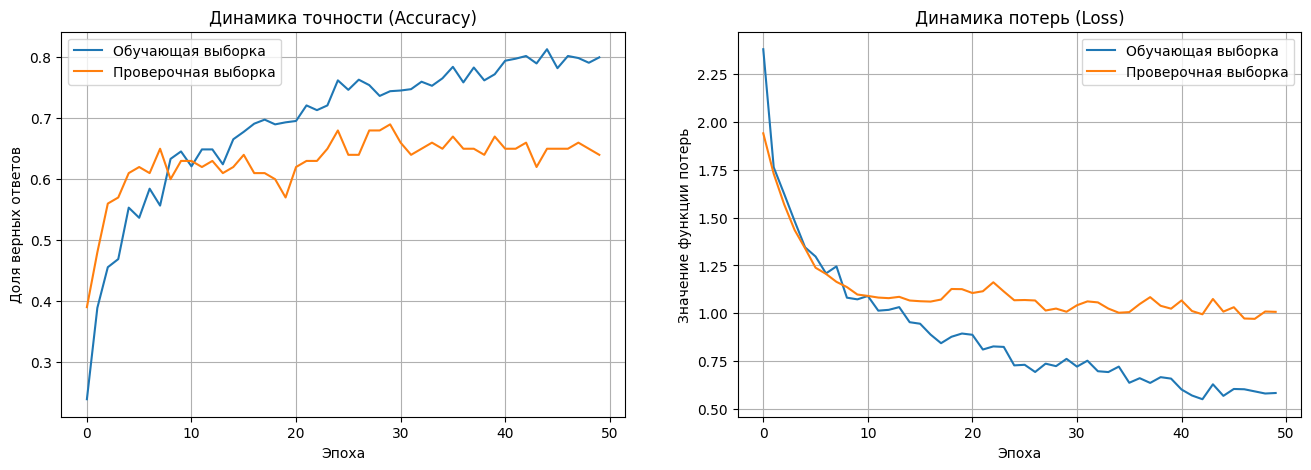


Итоговая точность модели на тестовых данных: 64.0%
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step


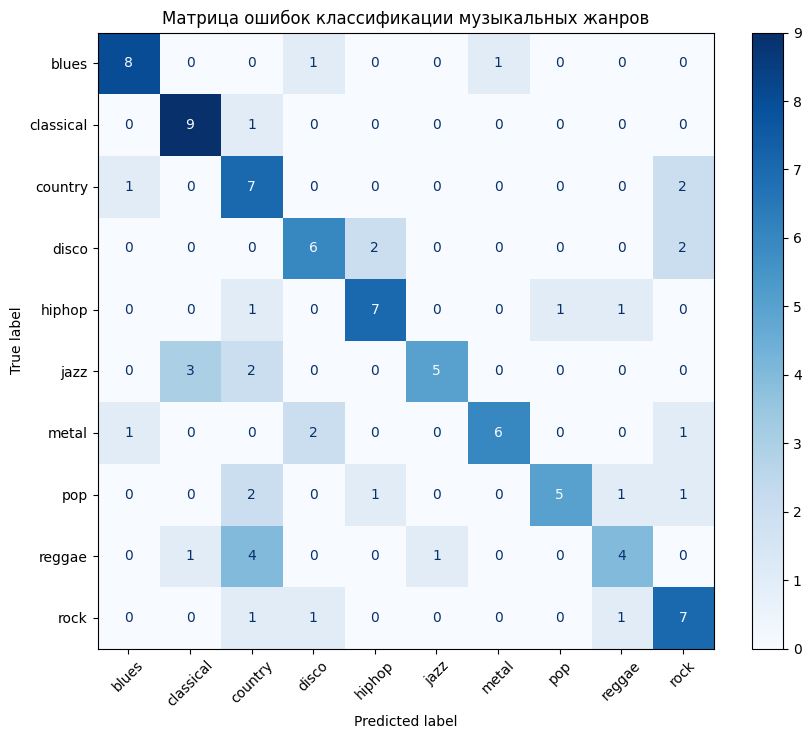

In [ ]:
# --- 1. Отрисовка графиков обучения ---
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# График Accuracy
axs[0].plot(history.history['accuracy'], label='Обучающая выборка')
axs[0].plot(history.history['val_accuracy'], label='Проверочная выборка')
axs[0].set_title('Динамика точности (Accuracy)')
axs[0].set_xlabel('Эпоха')
axs[0].set_ylabel('Доля верных ответов')
axs[0].legend()
axs[0].grid(True)

# График Loss
axs[1].plot(history.history['loss'], label='Обучающая выборка')
axs[1].plot(history.history['val_loss'], label='Проверочная выборка')
axs[1].set_title('Динамика потерь (Loss)')
axs[1].set_xlabel('Эпоха')
axs[1].set_ylabel('Значение функции потерь')
axs[1].legend()
axs[1].grid(True)

plt.show()

# --- 2. Получение предсказаний и расчет итоговой точности ---
loss, accuracy = model.evaluate(x_test_scaled, y_test_cat, verbose=0)
print(f"\nИтоговая точность модели на тестовых данных: {round(accuracy * 100, 2)}%")

# --- 3. Построение матрицы ошибок (Confusion Matrix) ---
y_pred = model.predict(x_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1) # Перевод из вероятностей в индексы классов

cm = confusion_matrix(y_test, y_pred_classes)

# Визуализация матрицы ошибок
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title("Матрица ошибок классификации музыкальных жанров")
plt.show()